In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load/Prepare Data

In [8]:
# Load Values
values = pd.read_csv("../AblationStudy/metrics_evaluation.csv", index_col=0, header=[0, 1, 2])

# Daten für seaborn vorbereiten - von wide zu long format
data_long = []

# Über alle Metriken iterieren (Level 1)
metrics = values.columns.get_level_values(0).unique()

for metric in metrics:
    metric_data = values[metric]  # Alle Daten für diese Metric

    # Über alle Model/SimilarityType Kombinationen iterieren
    for model in metric_data.columns.get_level_values(0).unique():  # Level 2
        for sim_type in metric_data.columns.get_level_values(1).unique():  # Level 3
            try:
                column_values = metric_data[model, sim_type].dropna()

                for value in column_values:
                    data_long.append({
                        'Metric': metric,
                        'Model': model,
                        'SimilarityType': sim_type,
                        'Value': value
                    })
            except KeyError:
                # Falls diese Kombination nicht existiert
                continue

# DataFrame aus der Liste erstellen
df_long = pd.DataFrame(data_long)

metrics_list = df_long['Metric'].unique()

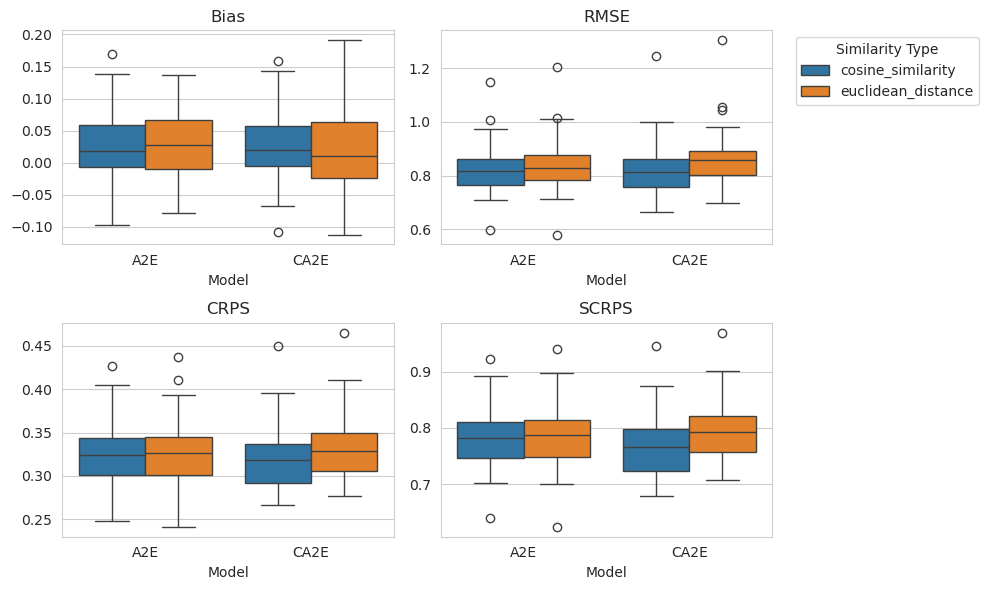

In [11]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 6))
axes = axes.flatten()

for i, metric in enumerate(metrics_list):
    if i < len(axes):
        metric_data = df_long[df_long['Metric'] == metric]

        sns.boxplot(
            data=metric_data,
            x='Model',
            y='Value',
            hue='SimilarityType',
            ax=axes[i],
            legend= i == 1
        )

        axes[i].set_title(f"{metric}")
        axes[i].set_xlabel('Model')
        axes[i].set_ylabel('')

axes[1].legend(title='Similarity Type', bbox_to_anchor=(1.05, 1), loc='upper left')

for i in range(len(metrics_list), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.savefig("../AblationStudy/metrics_boxplot.png")
plt.show()
plt.close()